<a href="https://colab.research.google.com/github/ethanresek/luminal-classifiers/blob/main/heat_map_to_compare_top_30_genes_in_SVM%2C_RF%2C_and_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Current directory: /content

Contents of plots/:
Saved: plots/cross_model_top30_heatmap.png


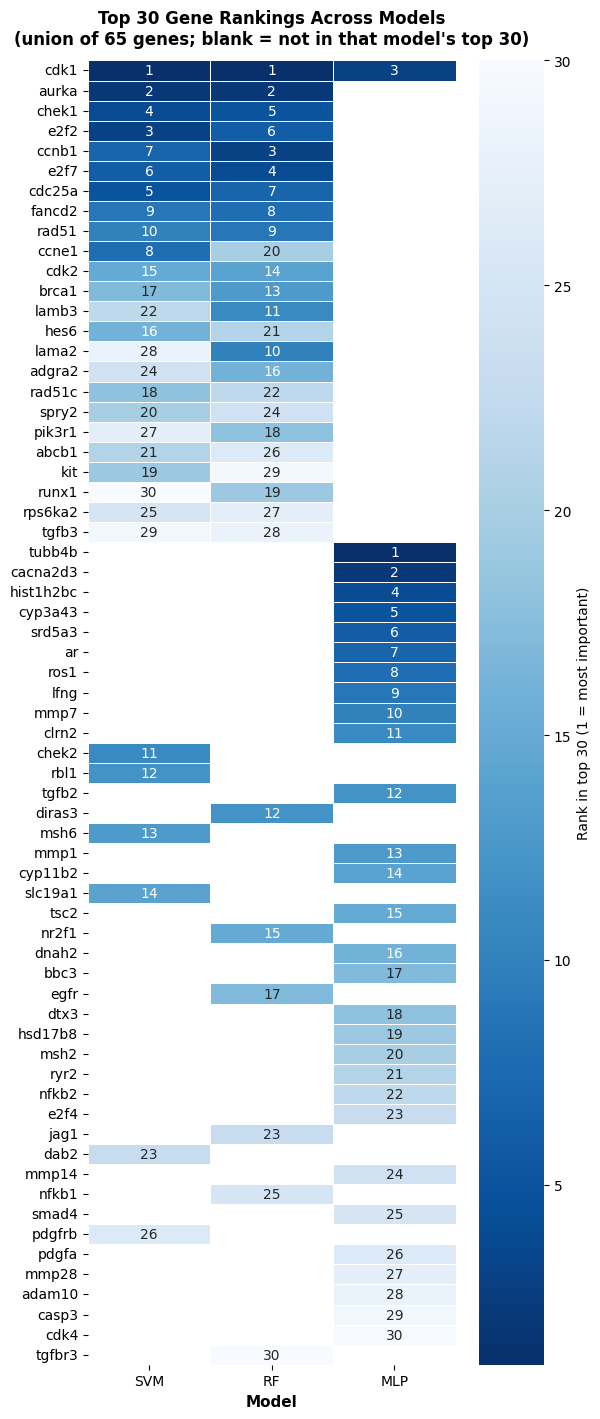


Genes in all 3 models: ['cdk1']
Genes in exactly 2 models: ['aurka', 'chek1', 'e2f2', 'ccnb1', 'e2f7', 'cdc25a', 'fancd2', 'rad51', 'ccne1', 'cdk2', 'brca1', 'lamb3', 'hes6', 'lama2', 'adgra2', 'rad51c', 'spry2', 'pik3r1', 'abcb1', 'kit', 'runx1', 'rps6ka2', 'tgfb3']
Genes in only 1 model: 41


In [2]:
# Cross-model top-30 gene heatmap
# Builds the union of the three models' top-30 gene lists, then shows which \
# model picked each gene and at what rank.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# top-30 lists (in rank order, rank 1 = most important)
svm_top30 = ['cdk1', 'aurka', 'e2f2', 'chek1', 'cdc25a', 'e2f7', 'ccnb1', 'ccne1',
             'fancd2', 'rad51', 'chek2', 'rbl1', 'msh6', 'slc19a1', 'cdk2', 'hes6',
             'brca1', 'rad51c', 'kit', 'spry2', 'abcb1', 'lamb3', 'dab2', 'adgra2',
             'rps6ka2', 'pdgfrb', 'pik3r1', 'lama2', 'tgfb3', 'runx1']

rf_top30  = ['cdk1', 'aurka', 'ccnb1', 'e2f7', 'chek1', 'e2f2', 'cdc25a', 'fancd2',
             'rad51', 'lama2', 'lamb3', 'diras3', 'brca1', 'cdk2', 'nr2f1', 'adgra2',
             'egfr', 'pik3r1', 'runx1', 'ccne1', 'hes6', 'rad51c', 'jag1', 'spry2',
             'nfkb1', 'abcb1', 'rps6ka2', 'tgfb3', 'kit', 'tgfbr3']

mlp_top30 = ['tubb4b', 'cacna2d3', 'cdk1', 'hist1h2bc', 'cyp3a43', 'srd5a3', 'ar', 'ros1',
             'lfng', 'mmp7', 'clrn2', 'tgfb2', 'mmp1', 'cyp11b2', 'tsc2', 'dnah2',
             'bbc3', 'dtx3', 'hsd17b8', 'msh2', 'ryr2', 'nfkb2', 'e2f4', 'mmp14',
             'smad4', 'pdgfa', 'mmp28', 'adam10', 'casp3', 'cdk4']

# Build union: shared-by-most first, then by average rank
all_genes = list(set(svm_top30) | set(rf_top30) | set(mlp_top30))

def rank_in(lst, g):
    return lst.index(g) + 1 if g in lst else np.nan

rank_df = pd.DataFrame({
    'SVM': [rank_in(svm_top30, g) for g in all_genes],
    'RF':  [rank_in(rf_top30,  g) for g in all_genes],
    'MLP': [rank_in(mlp_top30, g) for g in all_genes],
}, index=all_genes)

# Sort: first by how many models include the gene, then by average rank across
# models that included it (lower = higher up)
rank_df['n_models'] = rank_df[['SVM', 'RF', 'MLP']].notna().sum(axis=1)
rank_df['avg_rank'] = rank_df[['SVM', 'RF', 'MLP']].mean(axis=1)
rank_df = rank_df.sort_values(['n_models', 'avg_rank'], ascending=[False, True])

# Plot: cell colored by rank (darker = higher rank, more important); blank if
# gene not in that model's top-30
plot_data = rank_df[['SVM', 'RF', 'MLP']]

fig, ax = plt.subplots(figsize=(6, max(10, len(all_genes) * 0.22)))
sns.heatmap(plot_data, annot=True, fmt='.0f',
            cmap='Blues_r', vmin=1, vmax=30,
            cbar_kws={'label': 'Rank in top 30 (1 = most important)'},
            linewidths=0.5, linecolor='white',
            mask=plot_data.isna(),
            ax=ax)
ax.set_title(f'Top 30 Gene Rankings Across Models\n'
             f'(union of {len(all_genes)} genes; blank = not in that model\'s top 30)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()

import os
os.makedirs('plots', exist_ok=True)
print("Current directory:", os.getcwd())
print("\nContents of plots/:")
for f in os.listdir('plots'):
    full_path = os.path.join('plots', f)
    print(f"  {full_path}  ({os.path.getsize(full_path)/1024:.1f} KB)")
plt.savefig('plots/cross_model_top30_heatmap.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/cross_model_top30_heatmap.png', dpi=150, bbox_inches='tight')
print("Saved: plots/cross_model_top30_heatmap.png")
plt.show()